In [1]:
import jax.numpy as jnp
import numpy as np
import jax
from jax import grad, jit, random
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def generate_single_circle(normal, pts, m, phase=0.0):
    
    # Normalize just in case
    n = normal / jnp.linalg.norm(normal)
    v1 = jnp.array([1., 0., 0.]) if abs(n[0]) < 0.9 else jnp.array([0., 1., 0.])
    v1 = v1 - n * jnp.dot(n, v1)
    v1 /= jnp.linalg.norm(v1)
    v2 = jnp.cross(n, v1)

    # Apply phase shift directly to phi
    phi = jnp.linspace(0, 2*jnp.pi, pts, endpoint=False) + phase
    phi = phi % (2*jnp.pi)

    # Geometry on the sphere
    X = jnp.outer(jnp.cos(phi), v1) + jnp.outer(jnp.sin(phi), v2)

    # Circular harmonic ground truth
    y = jnp.sin(m * phi)

    return X, y

def generate_normals(K):

    # Fibonacci sphere sampling to get normals
    idx = jnp.arange(0, K, dtype=float) + 0.5
    phi = jnp.arccos(1 - 2 * idx / K)
    theta = jnp.pi * (1 + 5**0.5) * idx
    
    x = jnp.sin(phi) * jnp.cos(theta)
    y = jnp.sin(phi) * jnp.sin(theta)
    z = jnp.cos(phi)
    
    return jnp.vstack([x, y, z]).T

def generate_multi_great_circle_tasks(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    phase=0.0,
    random_phase=False
):
    normals = generate_normals(K_tasks)

    X_list, y_list, slices = [], [], []
    start = 0

    for j, n in enumerate(normals):
        if random_phase:
            phase_j = jnp.random.rand() * 2*jnp.pi
        else:
            phase_j = phase

        X, _ = generate_single_circle(n, pts_per_circle, m, phase=phase_j)
        y = np.zeros((X.shape[0],K_tasks))
        y[:,j]=1

        X_list.append(X)
        y_list.append(y)
        slices.append(slice(start, start + pts_per_circle))
        start += pts_per_circle

    return (
        jnp.vstack(X_list),
        jnp.concatenate(y_list),
        slices,
        normals,
    )

In [3]:
def run(
        K, # Number of tasks
        m, # Circular harmonic degree
        hidden_size,
        log_step,
        steps,
        pts_per_circle = 300,
        hidden_layer_num = 1,
        ):

    X, y, slices, normals = generate_multi_great_circle_tasks(
        K_tasks=K, pts_per_circle=pts_per_circle, m=m
    )

    X = jnp.array(X)
    Y = jnp.array(y)

    # set split fraction
    train_frac = 0.8
    n = X.shape[0]
    n_train = int(train_frac * n)

    # shuffle (with PRNG)
    key = jax.random.PRNGKey(42)
    perm = jax.random.permutation(key, n)

    X = X[perm]
    Y = Y[perm]

    # slice
    X_train, X_test = X[:n_train], X[n_train:]
    Y_train, Y_test = Y[:n_train], Y[n_train:]

    # define architecture
    layer_sizes = [3] + [hidden_size]*hidden_layer_num + [K]  # e.g., [3,512,512,...,K]

    # init all params
    key = random.PRNGKey(0)
    keys = random.split(key, len(layer_sizes))

    def init_mlp_params(sizes, keys):
        params = []
        for k, (in_dim, out_dim) in zip(keys, zip(sizes[:-1], sizes[1:])):
            W = random.normal(k, (in_dim, out_dim)) * jnp.sqrt(2/in_dim)
            b = jnp.zeros((out_dim,))
            params.append((W, b))
        return params

    params = init_mlp_params(layer_sizes, keys)

    # forward pass through L layers
    def forward(params, x):
        for i, (W, b) in enumerate(params[:-1]):
            x = jax.nn.relu(x @ W + b)
        W, b = params[-1]
        logits = x @ W + b
        return logits

    def loss_fn(params, x, y):
        logits = forward(params, x)
        loss = jnp.mean(-jnp.sum(y * jax.nn.log_softmax(logits), axis=1))
        return loss

    @jit
    def update(params, x, y, lr=1e-3):
        grads = grad(loss_fn)(params, x, y)
        return [(W - lr * dW, b - lr * db)
                for (W, b), (dW, db) in zip(params, grads)]


    results={'time':[], 'loss':[], 'acc':[]}

    # train for 200 steps
    for i in range(steps):
        params = update(params, X_train, Y_train)

        if i%log_step==0:
            results['time'].append(i)
            results['loss'].append(loss_fn(params, X_test, Y_test))
            results['acc'].append(jnp.mean(jnp.argmax(forward(params, X_test), axis=1) == jnp.argmax(Y_test, axis=1)))

    return results

We have 3 hyperparameters we can tune: K, hidden_size and points_per_circle. 

Classification accuracy vs training time for different K, fixed hidden size and pts_per_circle

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [05:36<00:00, 25.85s/it]


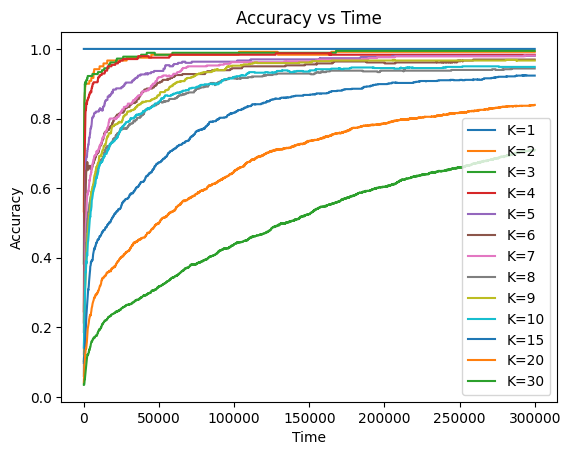

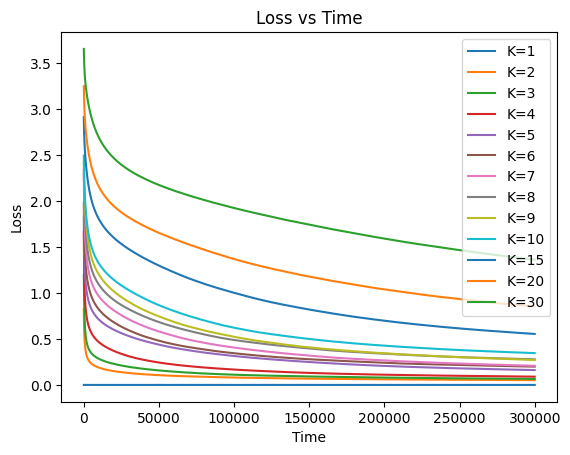

In [6]:
Ks = [1,2,3,4,5,6,7,8,9,10,15,20,30]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for K in tqdm(Ks):
    results = run(K=K, m=3, hidden_size=512, log_step=100, steps=300001, pts_per_circle=300)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"K={K}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"K={K}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

Let's take a look at K=30 and see if we can find a combination of the other two hyperparameters that fixes the convergence, or at least speeds it up

100%|██████████| 7/7 [15:40<00:00, 134.30s/it]


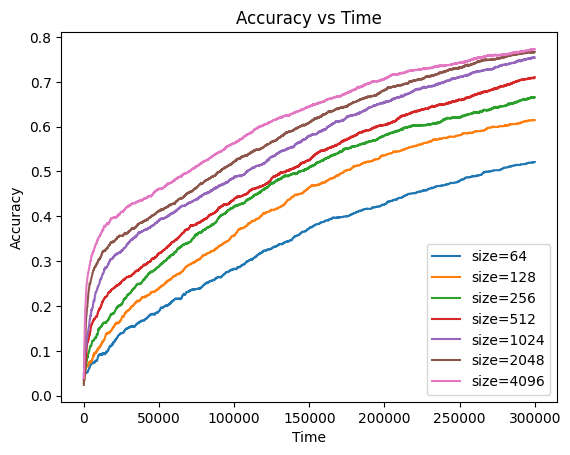

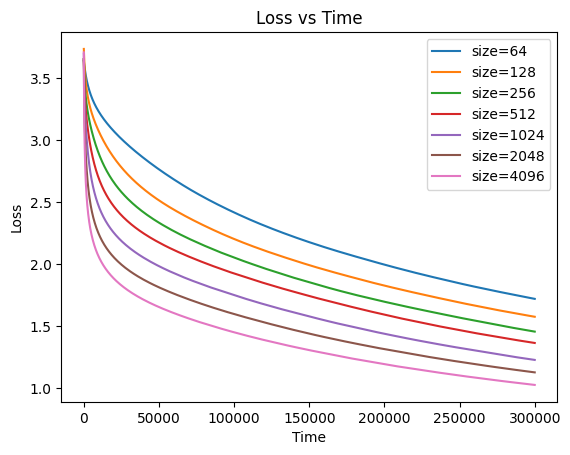

In [8]:
hidden_sizes = [64,128,256,512,1024,2048,4096]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for hidden_size in tqdm(hidden_sizes):
    results = run(K=30, m=3, hidden_size=hidden_size, log_step=100, steps=300001, pts_per_circle=300)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"size={hidden_size}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"size={hidden_size}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [24:53<00:00, 298.63s/it]


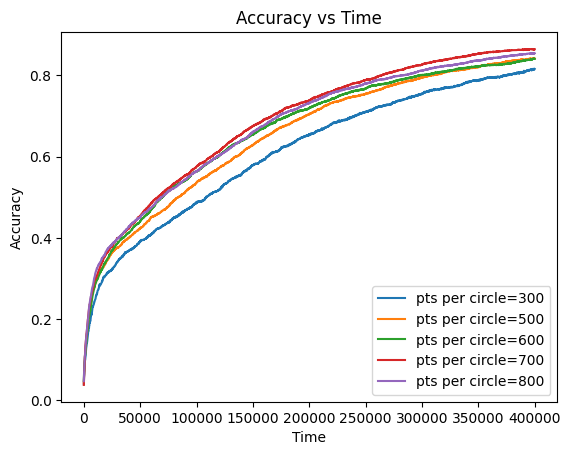

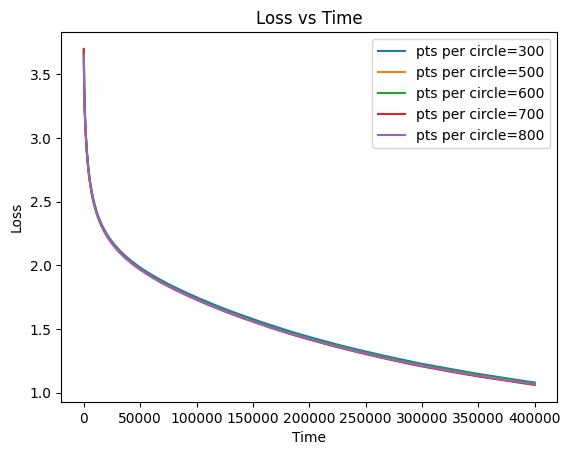

In [11]:
pts_per_circles = [300,500,600,700,800]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for pts_per_circle in tqdm(pts_per_circles):
    results = run(K=30, m=3, hidden_size=1024, log_step=100, steps=400001, pts_per_circle=pts_per_circle)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"pts per circle={pts_per_circle}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"pts per circle={pts_per_circle}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

In [ ]:
hidden_sizes = [256,512,1024,2048,4096]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for hidden_size in tqdm(hidden_sizes):
    results = run(K=30, m=3, hidden_size=hidden_size, log_step=100, steps=300001, pts_per_circle=512, hidden_layer_num=3)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"size={hidden_size}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"size={hidden_size}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

 60%|██████    | 3/5 [35:23<28:00, 840.18s/it]

#### Feasibility of computing analytical bias updates for finite networks and performance of the computed ones on the actual tasks

In [ ]:
from jax import jacrev, vmap

# Function to create parameters, we apply the NTK scaling here
def init_mlp_params(
    key,
    in_dim,
    hidden_dim,
    bias_mean=0.0,
    bias_std=0.0,
    weight_mean=0.0,
    weight_std=1.0,
):
    k1, k2, kb1, kb2 = random.split(key, 4)

    W1 = (random.normal(k1, (in_dim, hidden_dim)) * weight_std + weight_mean) / jnp.sqrt(in_dim)
    W2 = (random.normal(k2, (hidden_dim,)) * weight_std + weight_mean) / jnp.sqrt(hidden_dim)

    b1 = random.normal(kb1, (hidden_dim,)) * bias_std + bias_mean
    b2 = random.normal(kb2, ()) * bias_std + bias_mean

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

# Actual forward pass
def mlp_apply(params, x):
    h = jnp.maximum(0, x @ params["W1"] + params["b1"])
    return h @ params["W2"] + params["b2"]

# One pass through the net, this is needed for JAX computation reasons in automatic differentiation
def f_single(params, x):
    return mlp_apply(params, x)

# Function that, given parameters, gives the exact target labels for the generated data, solves the NTK bias solution
# analytically and computes (and returns) both the linearized model's solution with those updates and the actual model's
# prediction after the updates are applied.  
def get_ntk_pred(
    dim=16384,
    reg=1e-5,
    K=10,
    num_points=300,
    m=3,
    phase=0.0,
    bias_mean=0.0,
    bias_std=0.0,
    weight_mean=0.0,
    weight_std=1.0,
    key=random.PRNGKey(0),
):

    normals = generate_normals(K=K)

    key, subkey = random.split(key)
    params0 = init_mlp_params(
        subkey,
        in_dim=3,
        hidden_dim=dim,
        bias_mean=bias_mean,
        bias_std=bias_std,
        weight_mean=weight_mean,
        weight_std=weight_std,
    )

    results = {'lin':{}, 'nonlin':{}, 'y':{}}

    for j, normal in enumerate(normals):

        # Data
        X, y = generate_single_circle(normal, num_points, m, phase=phase)
        # Compute intial predictions (random)
        f0 = mlp_apply(params0, X)

        # Get bias terms of Jacobian
        J_tree = vmap(jacrev(f_single), (None, 0))(params0, X)
        Jb = jnp.concatenate([J_tree["b1"], J_tree["b2"][:,None]], axis=1)

        # Define the kernel and compute the regularization constant
        Kb = Jb @ Jb.T
        evals = jnp.linalg.eigvalsh(Kb)
        lam = reg * jnp.max(evals)

        # Find alpha and compute the updates with it
        alpha = jnp.linalg.solve(Kb + lam*jnp.eye(Kb.shape[0]), (y - f0))
        delta_b = Jb.T @ alpha

        # Compute new biases
        H = params0["b1"].shape[0]
        delta_b1 = delta_b[:H]
        delta_b2 = delta_b[H]

        params_A = dict(params0)
        params_A["b1"] += delta_b1
        params_A["b2"] += delta_b2

        # Get the linearized solution using the bias updates (the solution is off by a constant, since the tasks are 0 centered we recenter)
        f_lin = f0 + Jb @ delta_b
        f_lin -= jnp.mean(f_lin)

        # Do the same but getting the solution from the model with the new biases
        f_nonlin = mlp_apply(params_A, X)
        f_nonlin -= jnp.mean(f_nonlin)

        results['lin'][j] = f_lin
        results['nonlin'][j] = f_nonlin
        results['y'][j] = y

    return results

Over how many tasks should I average?

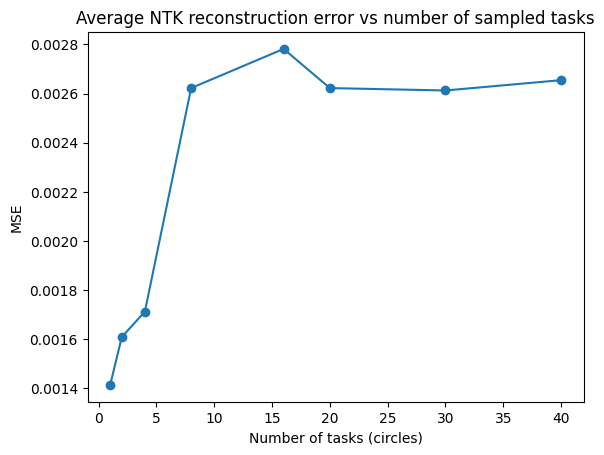

In [ ]:
# Some circles might, by chance, be slightly easier to learn, so we look where the avg MSE converges to a constant value.

Ks = [1,2,4,8,16,20,30,40]
dim = 16384

results_by_K = {}

for K in Ks:
    results_by_K[K] = get_ntk_pred(
        dim=dim,
        reg=1e-5,
        K=K,
        num_points=300,
        m=3,
        phase=0.0,
    )

mse_lin = []

for K in Ks:
    res = results_by_K[K]
    errs = [
        np.mean((res['lin'][j] - res['y'][j])**2)
        for j in res['lin'].keys()
    ]
    mse_lin.append(np.mean(errs))

plt.plot(Ks, mse_lin, marker='o')
plt.xlabel("Number of tasks (circles)")
plt.ylabel("MSE")
plt.title("Average NTK reconstruction error vs number of sampled tasks")
plt.show()

It seems like after 20 it's more or less stable, meaning we got both slightly "easier" and "harder".
We will use K=20 from now on.
Next step is to see how the MSE is dependent on the dimension of the hidden layer: we expect a decrease in MSE as the network approaches the infinite width limit.

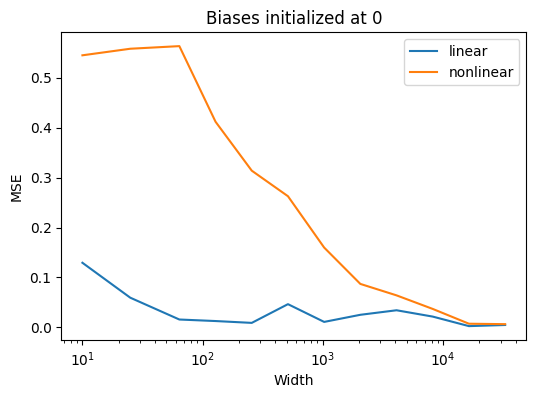

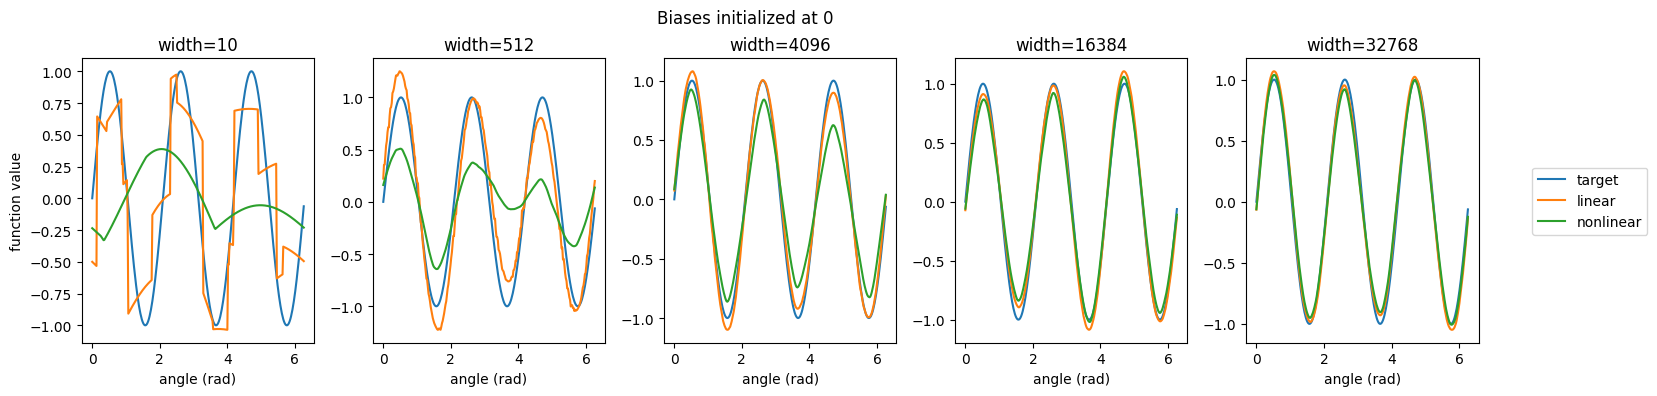

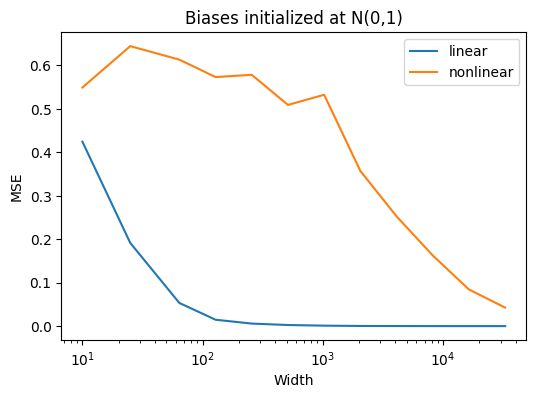

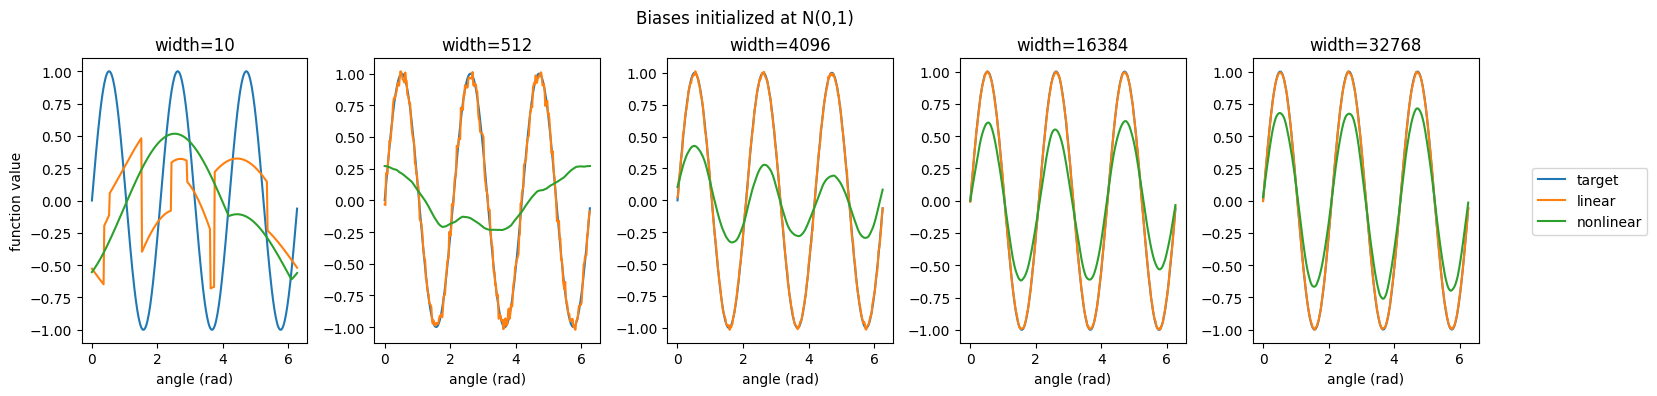

In [ ]:
# Gives the mse values (for the lin and nonlin approaches) given a set of results
def compute_mse_curve(results_per_dim, dims):
    mses = []

    for i in range(len(dims)):
        errs_lin = []
        errs_nonlin = []

        for j in results_per_dim[i]['lin'].keys():
            y = results_per_dim[i]['y'][j]
            errs_lin.append(np.mean((results_per_dim[i]['lin'][j] - y)**2))
            errs_nonlin.append(np.mean((results_per_dim[i]['nonlin'][j] - y)**2))

        mses.append({
            "lin": float(np.mean(errs_lin)),
            "nonlin": float(np.mean(errs_nonlin))
        })

    return mses

# Plots the actual predictions and the target values across different widths of the hidden layer
def plot_width_examples(results_per_dim, dims, widths_to_show, title):
    task_id = 0
    num_points = len(results_per_dim[0]['y'][task_id])
    phi = np.linspace(0, 2*np.pi, num_points, endpoint=False)

    fig, axes = plt.subplots(1, len(widths_to_show), figsize=(15,4))

    for ax, w in zip(axes, widths_to_show):
        i = dims.index(w)

        y = np.asarray(results_per_dim[i]['y'][task_id])
        f_lin = np.asarray(results_per_dim[i]['lin'][task_id])
        f_nonlin = np.asarray(results_per_dim[i]['nonlin'][task_id])

        ax.plot(phi, y, label="target")
        ax.plot(phi, f_lin, label="linear")
        ax.plot(phi, f_nonlin, label="nonlinear")
        ax.set_title(f"width={w}")
        ax.set_xlabel("angle (rad)")

    axes[0].set_ylabel("function value")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout(rect=[0,0,0.999,0.95])
    plt.suptitle(title)
    plt.show()

# Runs the function to get the predictions, for different hidden sizes and specific bias std
def run_width_sweep(bias_std, dims):

    results_per_dim = []

    for d in dims:
        res = get_ntk_pred(
            dim=d,
            reg=1e-5,
            K=20,
            num_points=300,
            m=3,
            phase=0.0,
            bias_mean=0,
            bias_std=bias_std,
        )
        results_per_dim.append(res)

    return results_per_dim

# Do experiment for biases initialized at 0 (std=0)
dims = [10,25,64,128,256,512,1024,2048,4096,8192,16384,32768]
widths_to_show = [10,512,4096,16384,32768]

results_zero = run_width_sweep(bias_std=0, dims=dims)

mse_zero = compute_mse_curve(results_zero, dims)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(dims, [d['lin'] for d in mse_zero], label='linear')
ax.plot(dims, [d['nonlin'] for d in mse_zero], label='nonlinear')
ax.set_xscale("log")
ax.set_xlabel("Width")
ax.set_ylabel("MSE")
ax.set_title("Biases initialized at 0")
ax.legend()
plt.show()

plot_width_examples(results_zero, dims, widths_to_show,
                    title="Biases initialized at 0")

# Do experiment for biases initialized as N(0,1) (std=1)
results_rand = run_width_sweep(bias_std=1, dims=dims)

mse_rand = compute_mse_curve(results_rand, dims)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(dims, [d['lin'] for d in mse_rand], label='linear')
ax.plot(dims, [d['nonlin'] for d in mse_rand], label='nonlinear')
ax.set_xscale("log")
ax.set_xlabel("Width")
ax.set_ylabel("MSE")
ax.set_title("Biases initialized at N(0,1)")
ax.legend()
plt.show()

plot_width_examples(results_rand, dims, widths_to_show,
                    title="Biases initialized at N(0,1)")

Strangely, if we set the biases to 0, the nonlinear case works better, while if we set the biases to N(0,1) the linear approximation works better.
We can still observe the spectral bias baked into the NTK if we try representing even and odd functions. We can solve the problem in the same way we already did.

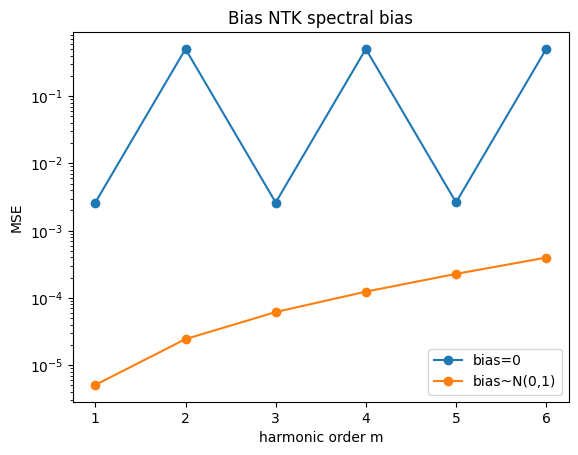

In [ ]:
# Gets the results for a set of harmonic degrees of the target function
def run_harmonic_sweep(ms, dim, bias_mean=0, bias_std=0, K=20):
    results_by_m = {}

    for m in ms:
        results_by_m[m] = get_ntk_pred(
            dim=dim,
            reg=1e-5,
            K=K,
            num_points=300,
            m=m,
            phase=0.0,
            bias_mean=bias_mean,
            bias_std=bias_std,
        )

    mse = []
    for m in ms:
        res = results_by_m[m]
        errs = [
            np.mean((res['lin'][j] - res['y'][j])**2)
            for j in res['lin'].keys()
        ]
        mse.append(np.mean(errs))

    return mse

# Run the experiment
ms = [1,2,3,4,5,6]
dim = 16384

mse_zero = run_harmonic_sweep(ms, dim, bias_mean=0, bias_std=0, K=20)
mse_rand = run_harmonic_sweep(ms, dim, bias_mean=0, bias_std=1, K=20)

plt.plot(ms, mse_zero, marker='o', label='bias=0')
plt.plot(ms, mse_rand, marker='o', label='bias~N(0,1)')
plt.yscale("log")
plt.xlabel("harmonic order m")
plt.ylabel("MSE")
plt.title("Bias NTK spectral bias")
plt.legend()
plt.show()

We can take a look at how the number of points per circle impacts performance.

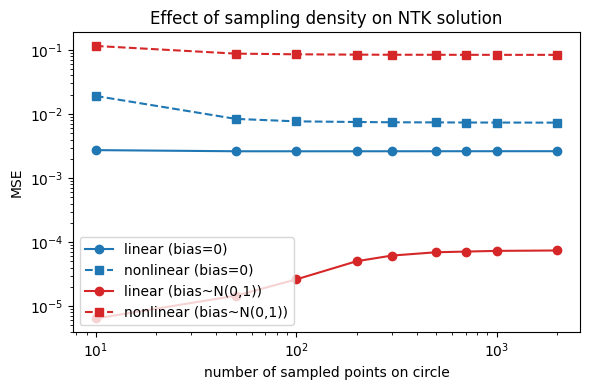

In [ ]:
# Gets the predictions for different amounts of num_points, meaning different sampling of the circle in 3D 
def run_sampling_sweep(num_points_list, dim, bias_mean=0, bias_std=0, K=20):
    results_by_pts = {}

    for n in num_points_list:
        results_by_pts[n] = get_ntk_pred(
            dim=dim,
            reg=1e-5,
            K=K,
            num_points=n,
            m=3,
            phase=0.0,
            bias_mean=bias_mean,
            bias_std=bias_std,
        )

    mse_lin = []
    mse_nonlin = []

    for n in num_points_list:
        res = results_by_pts[n]
        errs_lin = [
            np.mean((res['lin'][j] - res['y'][j])**2)
            for j in res['lin'].keys()
        ]
        errs_nonlin = [
            np.mean((res['nonlin'][j] - res['y'][j])**2)
            for j in res['nonlin'].keys()
        ]

        mse_lin.append(np.mean(errs_lin))
        mse_nonlin.append(np.mean(errs_nonlin))

    return mse_lin, mse_nonlin

# Run the experiment
num_points_list = [10,50,100,200,300,500,700,1000,2000]
dim = 16384

mse_zero_lin, mse_zero_nonlin = run_sampling_sweep(
    num_points_list, dim, bias_mean=0, bias_std=0
)

mse_rand_lin, mse_rand_nonlin = run_sampling_sweep(
    num_points_list, dim, bias_mean=0, bias_std=1
)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(num_points_list, mse_zero_lin,
        color="tab:blue", marker="o", label="linear (bias=0)")
ax.plot(num_points_list, mse_zero_nonlin,
        color="tab:blue", marker="s", linestyle="--",
        label="nonlinear (bias=0)")
ax.plot(num_points_list, mse_rand_lin,
        color="tab:red", marker="o", label="linear (bias~N(0,1))")
ax.plot(num_points_list, mse_rand_nonlin,
        color="tab:red", marker="s", linestyle="--",
        label="nonlinear (bias~N(0,1))")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("number of sampled points on circle")
ax.set_ylabel("MSE")
ax.set_title("Effect of sampling density on NTK solution")
ax.legend()

plt.tight_layout()
plt.show()